# Setup

In [2]:
from datasets import load_dataset

ds = load_dataset("AKCIT/MedPT")

README.md:   0%|          | 0.00/5.83k [00:00<?, ?B/s]

data/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 95.1MB            

data/train-00000-of-00001.parquet: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/384095 [00:00<?, ? examples/s]

# EDA

In [3]:
df = ds['train'].to_pandas()

print("\n\n======== Heads ========")
print(f"Train:\n{df.head()}\n\n")
print("======== Heads ========\n\n")

print("\n\n======== Shape ========")
print(f"Train:\n{df.shape}\n\n")
print("======== Shape ========\n\n")

print("\n\n======== Types ========")
print(f"Train:\n{df.dtypes}\n\n")
print("======== Types ========\n\n")

print("\n\n======== Amount of Null Values ========")
print(f"Train:\n{df.isna().sum()}\n\n")
print("======== Amount of Null Values ========\n\n")

print("\n\n======== Amount of Duplicate Values ========")
print(f"Train:\n{df.duplicated().sum()}\n\n")
print("======== Amount of Duplicate Values ========\n\n")

print("\n\n======== Categories ========")
print(f"Train:\n{df['question_type'].value_counts()}\n\n")
print("======== Categories ========\n\n")

print("\n\n======== Describe ========")
print(f"Train:\n{df['question_type'].describe()}\n\n")
print("======== Describe ========\n\n")




======== Heads ========
Train:
   id                                           question  \
0   0  Fazer aplicação de ácido hialurônico no ombro ...   
1   1  Fazer aplicação de ácido hialurônico no ombro ...   
2   2  Posso fazer uso regularmente de alupurinol dia...   
3   4         O que é artrite gotosa?o que provoca isto?   
4   5         O que é artrite gotosa?o que provoca isto?   

                                              answer          condition  \
0         Pode funcionar,associado com fisioterapia.  Capsulite adesiva   
1  O bloqueio do movimento causado pela Capsulite...  Capsulite adesiva   
2  Olá! Sim, pode ser necessário utilizar medicaç...     Artrite Gotosa   
3  Artrite gotosa é A inflamação de uma articulaç...     Artrite Gotosa   
4  A artrite gotosa é uma inflamação dentro da ar...     Artrite Gotosa   

                                 medical_specialty question_type  
0                    Ortopedista - traumatologista    Tratamento  
1                    

# Gráficos

<Axes: xlabel='question_type'>

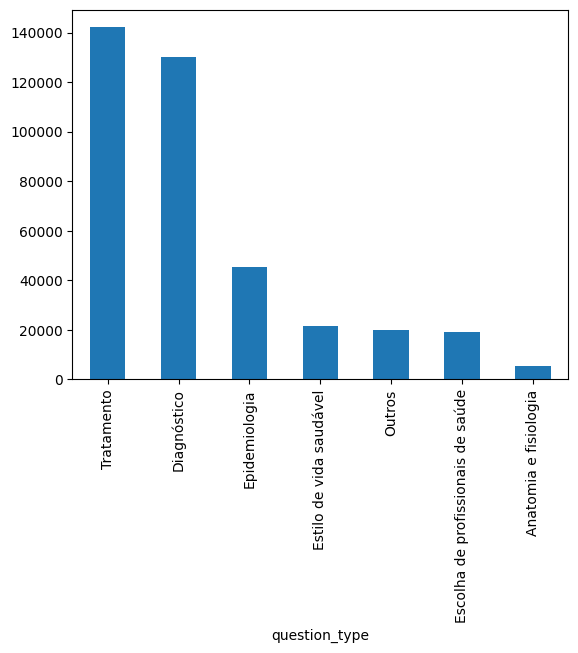

In [4]:

df['question_type'].value_counts().plot(kind="bar")

### Análise do Gráfico de Barras

É possível notar que as categorias de tratamento e diagnóstico, estão, consideravelmente mais elevadas que as demais. Isso muito provavelmente indica uma tendência dos usuários a procurarem ajuda na plataforma quando já tem algum sintoma ou problema de saúde e buscam compreender o que pode estar acontecendo ou possibilidades de tratamento.

<Axes: ylabel='Frequency'>

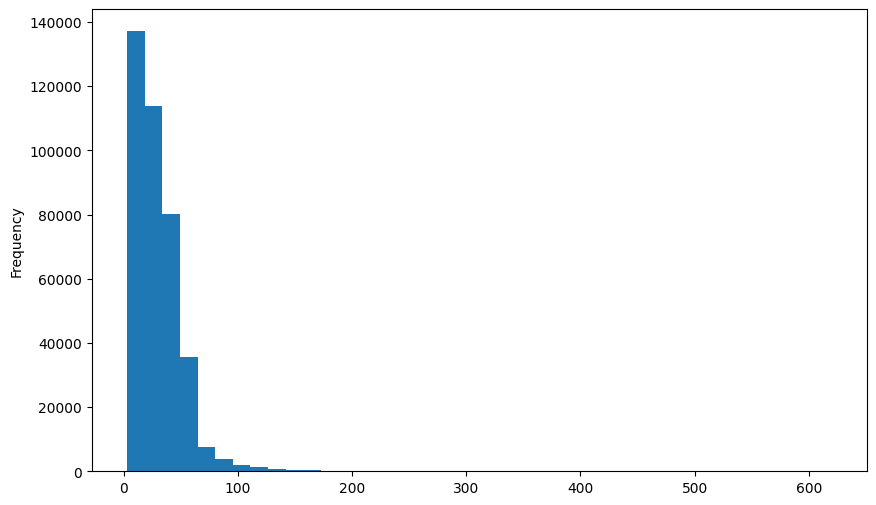

In [5]:
df["question_word_count"] = df["question"].str.split().str.len()
df["question_word_count"].plot(kind="hist", bins=40, figsize=(10, 6))

<Axes: ylabel='Frequency'>

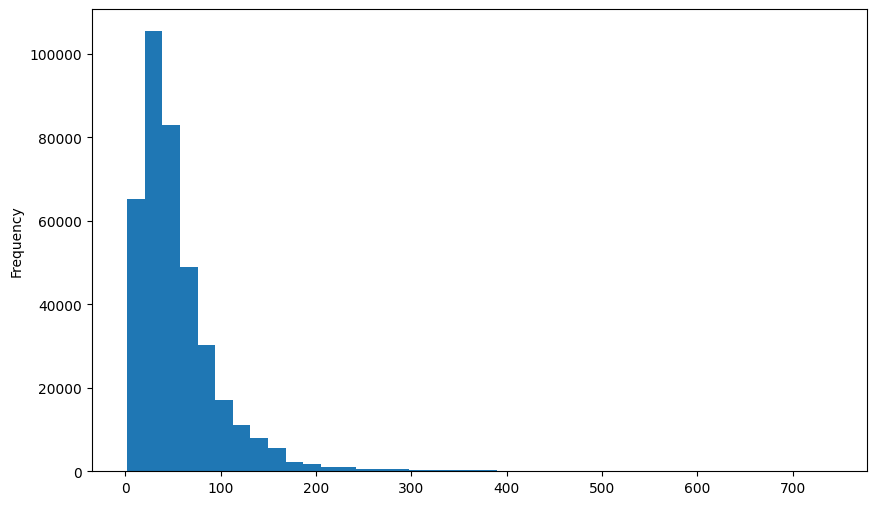

In [6]:
df["answer_word_count"] = df["answer"].str.split().str.len()
df["answer_word_count"].plot(kind="hist", bins=40, figsize=(10, 6))

### Análise Histogramas:

É notável através dos gráficos acima que a maioria das pessoas utilizaram menos de 100 palavras para descreverem suas questões, com uma aparente preferência por questões mais curtas.

Nas respostas dos profissionais a tendência é a mesma porém é visível que algumas ultrapassam esse limite podendo chegar a mais de 400 palavras.

Isso é interessante pois indica que podemos esperar entradas mais curtas mas que devemos estar preparados para as raras ocasiões onde o usuário coloque uma entrada mais extensa e descritiva.

<Axes: title={'center': 'question_word_count'}, xlabel='[question_type]'>

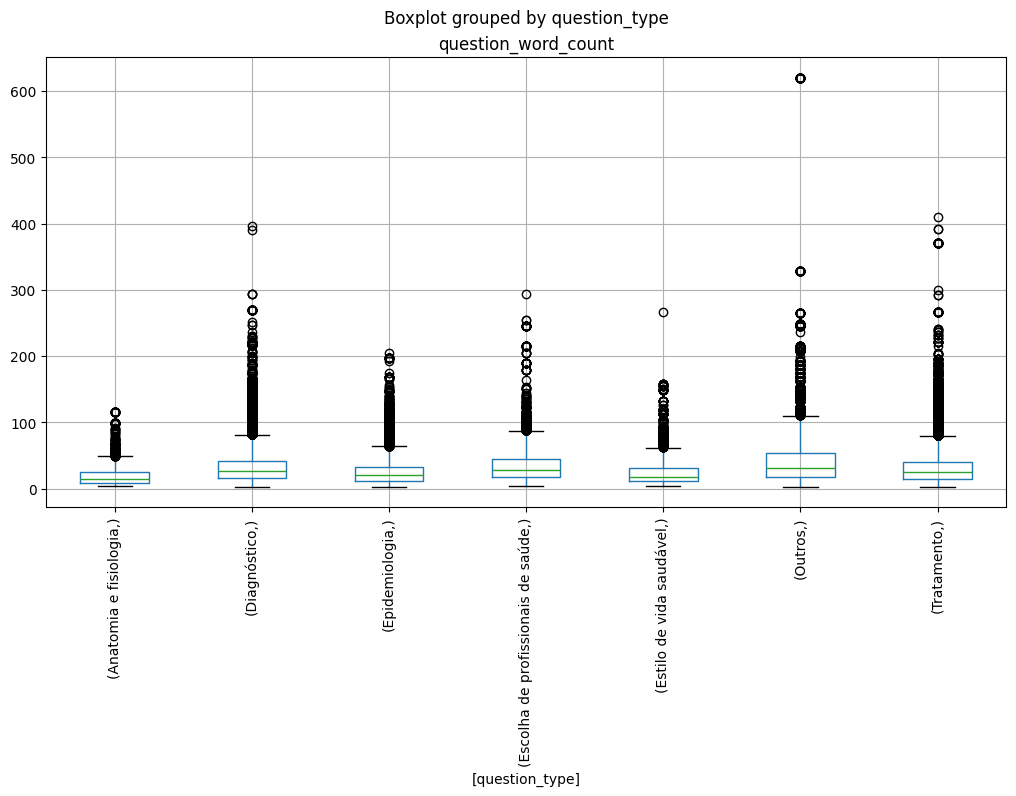

In [7]:
df.boxplot(column=["question_word_count"], by=["question_type"], figsize=(12, 6), rot=90)

<Axes: title={'center': 'answer_word_count'}, xlabel='[question_type]'>

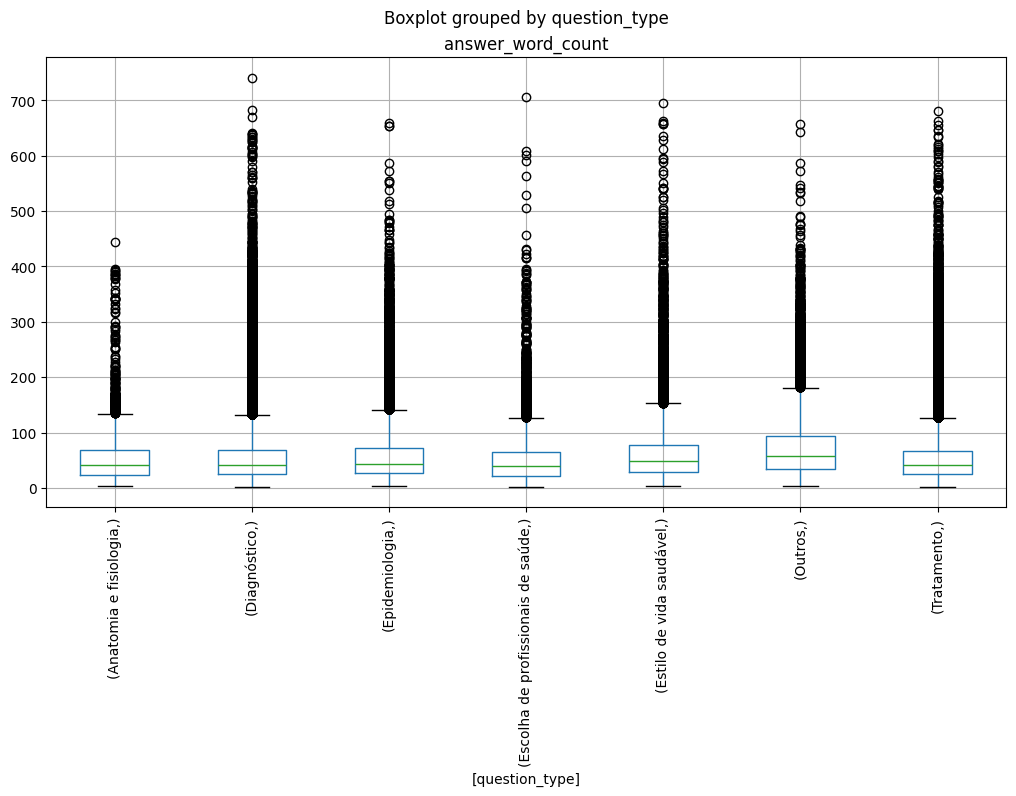

In [8]:
df.boxplot(column=["answer_word_count"], by=["question_type"], figsize=(12, 6), rot=90)

### Análise Boxplots

Os boxplots reforçam os histogramas, mostrando que na maioria das categorias as perguntas se concentram em uma mediana de aproximadamente 15 a 40 palavras, ao mesmo tempo, vemos algo que estava mais discreto ou até mesmo não visível nos histogramas, os outliers que podem chegar a 300, 400 ou até mesmo 600 palavras, portanto, mesmo que o comportamento típico seja de uma mediana de aproximadamente de 15 a 40 palavras, não podemos assumir que o usuário final sempre vai inserir um tamanho nessa média.

Nas respostas dos profissionais é possível observar o mesmo padrão, com a grande maioria tendo uma mediana de aproximadamente de 40 a 60 palavras, mas com grande número de outliers chegando a 600 e até mesmo a 700 palavras, demonstrando grande diversidade no tamanho das respostas fornecidas, também é notavel que algumas categorias como “Estilo de Vida Saudável” ou “Outros” tem uma média maior de palavras, o que pode indicar que algumas categorias tendem a demandar respostas mais explicativas e maiores.